# Predictive HR Analytics: Employee Attrition & Workforce Insights Using Python

**Name** : Kushal Roy \
**PRN** : 220105011003

**Project Introduction**

Employee attrition is a critical challenge for organizations as it affects productivity, recruitment costs, and workforce stability. This project focuses on analyzing employee data to identify patterns and factors influencing attrition.

Using Python-based data analytics techniques, the project explores workforce trends, department-wise attrition, salary distribution, work-life balance impact, and predictive modeling. The analysis helps HR professionals make data-driven decisions to improve employee retention and workforce management.

Tools used in this project include Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the Dataset
df = pd.read_csv("hr_attrition_dataset_15000.csv")
df.head()

,EmployeeID,Age,Gender,Education,Department,JobRole,Salary,YearsAtCompany,WorkLifeBalance,TrainingHours,PerformanceRating,Attrition
0,1,49,Male,Bachelors,Customer Support,Support Manager,128694,10,4,6,2,Yes
1,2,44,Female,MBA,IT,IT Manager,69131,7,4,4,2,No
2,3,22,Female,PhD,Operations,Operations Manager,30311,20,1,5,5,No
3,4,48,Female,Masters,HR,HR Executive,27747,15,3,2,4,No
4,5,57,Male,Bachelors,HR,HR Executive,28890,6,1,1,4,No


In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   EmployeeID         15000 non-null  int64 
 1   Age                15000 non-null  int64 
 2   Gender             15000 non-null  object
 3   Education          15000 non-null  object
 4   Department         15000 non-null  object
 5   JobRole            15000 non-null  object
 6   Salary             15000 non-null  int64 
 7   YearsAtCompany     15000 non-null  int64 
 8   WorkLifeBalance    15000 non-null  int64 
 9   TrainingHours      15000 non-null  int64 
 10  PerformanceRating  15000 non-null  int64 
 11  Attrition          15000 non-null  object
dtypes: int64(7), object(5)
memory usage: 1.4+ MB


In [6]:
# Summary Statistics
df.describe()

,EmployeeID,Age,Salary,YearsAtCompany,WorkLifeBalance,TrainingHours,PerformanceRating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,39.957600,87088.407933,12.070600,2.499933,4.513200,3.008133
std,4330.271354,11.252157,36022.032062,7.204888,1.130878,2.868747,1.415886
min,1.000000,21.000000,25015.000000,0.000000,1.000000,0.000000,1.000000
25%,3750.750000,30.000000,55786.000000,6.000000,1.000000,2.000000,2.000000
50%,7500.500000,40.000000,86872.500000,12.000000,3.000000,5.000000,3.000000
75%,11250.250000,50.000000,118169.750000,18.000000,4.000000,7.000000,4.000000
max,15000.000000,59.000000,149990.000000,24.000000,4.000000,9.000000,5.000000


In [7]:
# Attrition Distribution
df["Attrition"].value_counts()

,count
Attrition,
No,11749
Yes,3251


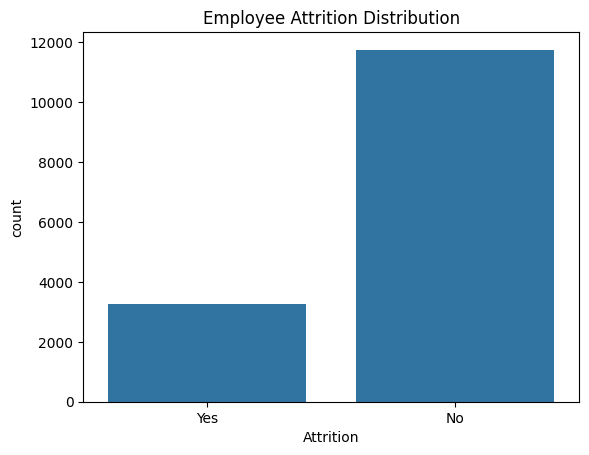

In [9]:
# Attrition Distribution Visualization
plt.figure()
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.show()

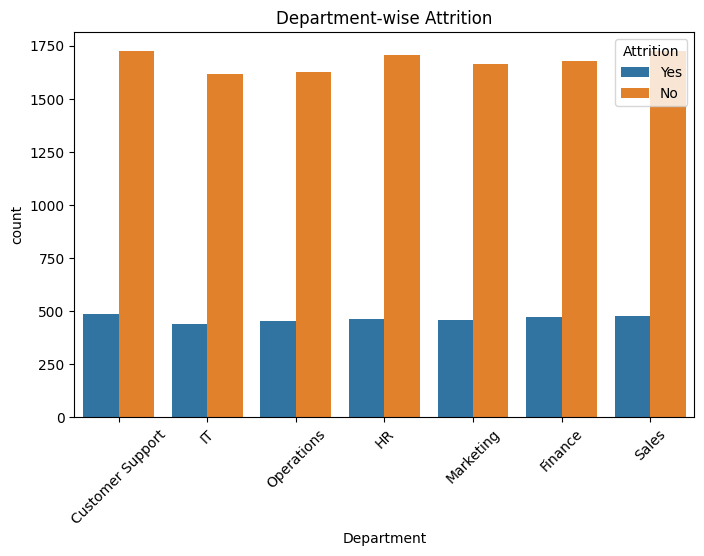

In [10]:
# Attrition by Department
plt.figure(figsize=(8,5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.xticks(rotation=45)
plt.title("Department-wise Attrition")
plt.show()

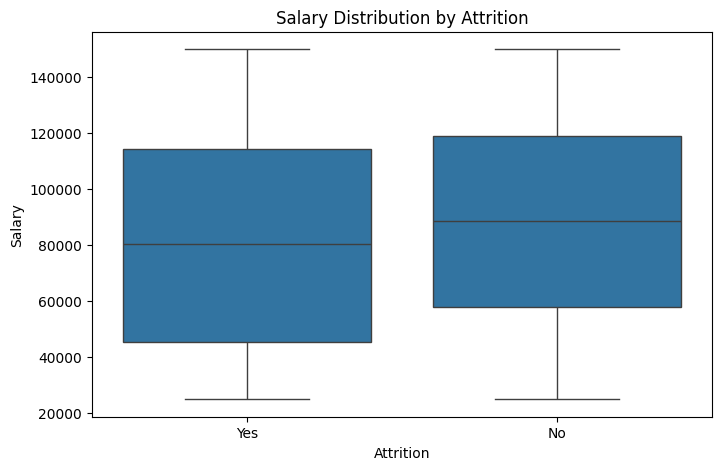

In [11]:
# Salary vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="Salary", data=df)
plt.title("Salary Distribution by Attrition")
plt.show()

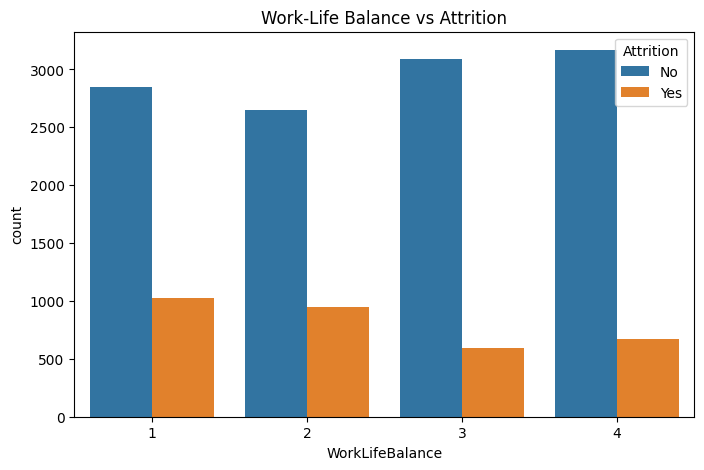

In [12]:
# Work-Life Balance Impact
plt.figure(figsize=(8,5))
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df)
plt.title("Work-Life Balance vs Attrition")
plt.show()

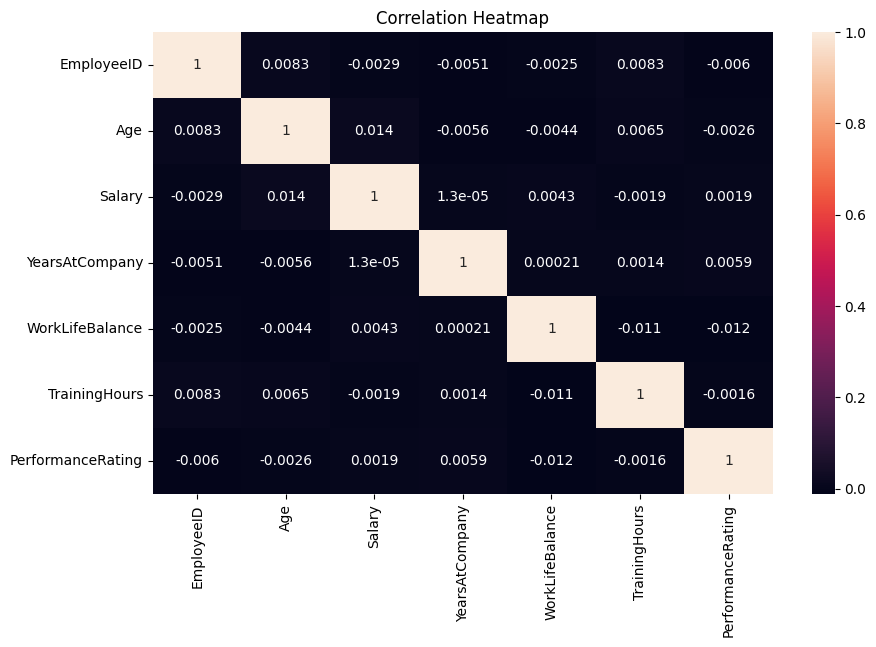

In [13]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Encode Categorical Data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])
df["Department"] = le.fit_transform(df["Department"])
df["JobRole"] = le.fit_transform(df["JobRole"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Education"] = le.fit_transform(df["Education"])

In [17]:
# Define Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [20]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Define Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [22]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# Train Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [25]:
# Accuracy
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7923333333333333


In [26]:
# Model Evaluation
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      2377
           1       0.00      0.00      0.00       623

    accuracy                           0.79      3000
   macro avg       0.40      0.50      0.44      3000
weighted avg       0.63      0.79      0.70      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


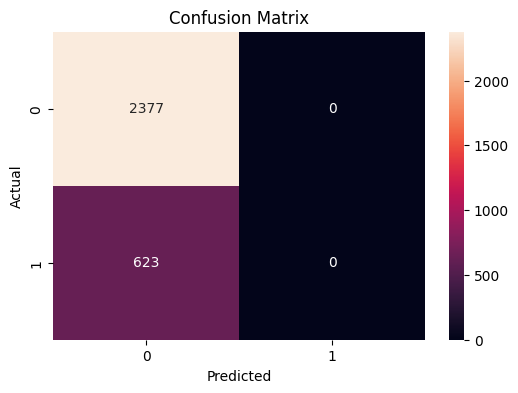

In [27]:
# Confusion Matrix visualization
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
# Advanced HR Analytics Modeling
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_accuracy = rf_model.score(X_test, y_test)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7903333333333333


In [29]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
6,Salary,0.236585
0,EmployeeID,0.157449
1,Age,0.108544
7,YearsAtCompany,0.105591
5,JobRole,0.084938
8,WorkLifeBalance,0.075617
9,TrainingHours,0.072711
10,PerformanceRating,0.049616
4,Department,0.045915
3,Education,0.042892


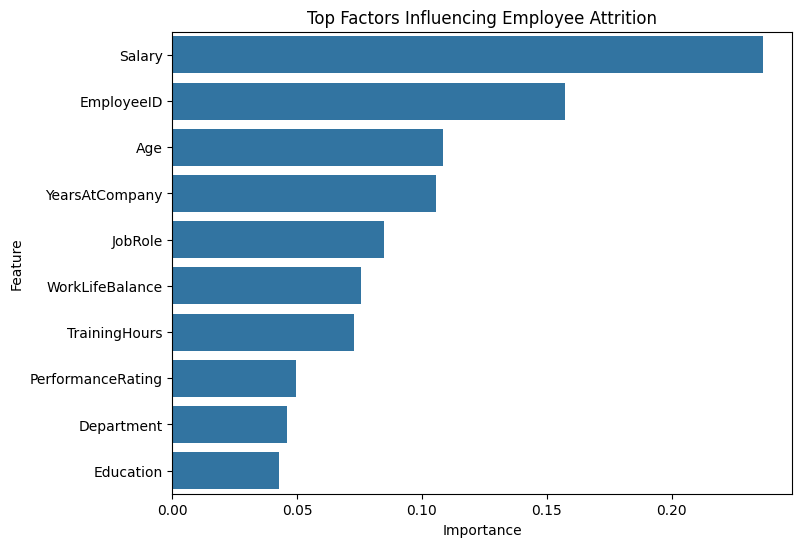

In [32]:
# Feature Importance Graph
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top Factors Influencing Employee Attrition")
plt.show()

In [33]:
# Attrition Risk Prediction
attrition_probability = rf_model.predict_proba(X_test)[:,1]

risk_df = pd.DataFrame({
    "Actual": y_test,
    "Attrition_Risk": attrition_probability
})
risk_df.head()

,Actual,Attrition_Risk
11499,0,0.180555
6475,0,0.256108
13167,0,0.238430
862,1,0.173754
5970,1,0.132792


In [34]:
# Employee Risk Segmentation
risk_df["Risk_Level"] = pd.cut(
    risk_df["Attrition_Risk"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)
risk_df["Risk_Level"].value_counts()

,count
Risk_Level,
Low Risk,2631
Medium Risk,367
High Risk,2


**HR Business Insights**

**Key Findings**

1. Employees with low work-life balance show higher attrition probability
2. Early-tenure employees show greater turnover risk
3. Salary levels strongly influence retention

**HR Recommendations**

1. Improve employee engagement programs
2. Strengthen retention for early-tenure employees
3. Implement salary benchmarking strategies

In [35]:
# Model Comparison Table
from sklearn.metrics import accuracy_score
lr_pred = model.predict(X_test)
rf_pred = rf_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.792333
1,Random Forest,0.790333


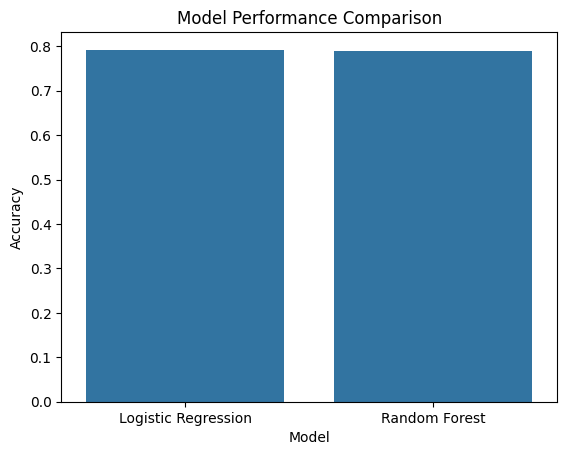

In [36]:
# Model Comparison Table Optional visualization:
plt.figure()
sns.barplot(x="Model", y="Accuracy", data=comparison)
plt.title("Model Performance Comparison")
plt.show()

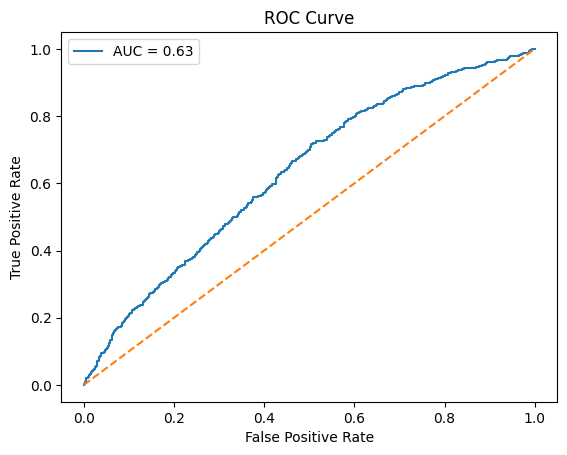

In [37]:
# ROC Curve (Professional Model Evaluation)
from sklearn.metrics import roc_curve, auc
probs = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [38]:
# Department Attrition Rate Analysis
dept_attrition = df.groupby("Department")["Attrition"].mean()
dept_attrition

,Attrition
Department,
0,0.218807
1,0.219954
2,0.213001
3,0.214390
4,0.216102
5,0.217684
6,0.217075


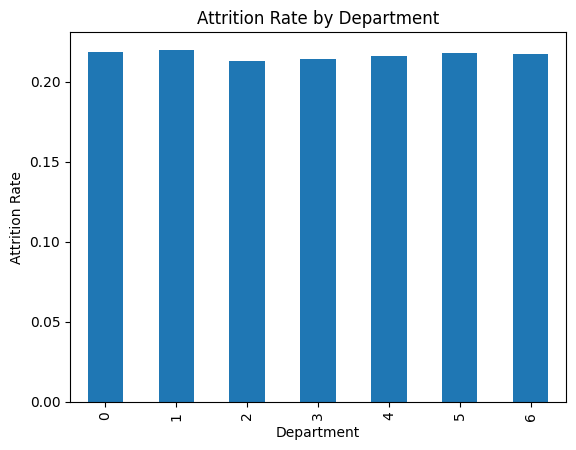

In [39]:
# Department Attrition Rate Analysis Visualization
plt.figure()
dept_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.show()

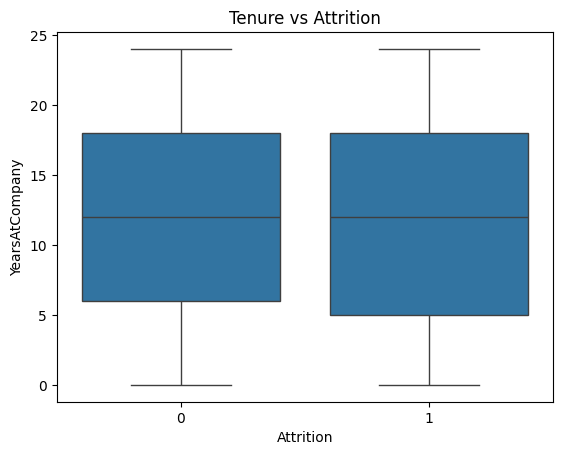

In [40]:
# Tenure vs Attrition Analysis
plt.figure()
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Tenure vs Attrition")
plt.show()

**Strategic** **HR Recommendations**
1. Develop targeted retention programs for employees with high attrition risk.
2. Improve work-life balance policies to reduce voluntary turnover.
3. Focus retention efforts on departments with the highest attrition rates.
4. Implement predictive HR dashboards to monitor workforce stability.